> ### Note on Labs and Assigments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 5: EDA

## Outline

- Data quality checks: data types, missing values, duplicates and outliers
- Descriptive statistics
- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab uses the same dataset from **Lab 4**. Data on Bay Area Craigslist rental housing posts.

Source: Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

If you have any questions about Colab, you can read more here:  
https://research.google.com/colaboratory/faq.html


## Dataset Overview

**Dataset:** `rent.csv`  
Source: [TidyTuesday – 2022-07-05](https://github.com/rfordatascience/tidytuesday/blob/main/data/2022/2022-07-05/rent.csv)

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## Part 1: Import libraries, and the Data, and preview the Data

### Instructions:
- Import the `pandas` library.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `df.shape`, `df.info()` and `df.head()` to inspect the structure and preview the data.

In [3]:
# import any libraries that you wish to use
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# read in the data
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/rent.csv'
df = pd.read_csv(url)



In [4]:
df.shape

(200796, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200796 entries, 0 to 200795
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200796 non-null  object 
 1   date         200796 non-null  int64  
 2   year         200796 non-null  int64  
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  int64  
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  int64  
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8016 non-null    object 
dtypes: float64(5), int64(4), object(8)
memory usage: 26.0+ MB


In [6]:

df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005,alameda,alameda,alameda,1250,2.0,2.0,NaN,0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005,alameda,alameda,alameda,1295,2.0,NaN,NaN,0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004,alameda,alameda,alameda,1100,2.0,NaN,NaN,0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012,alameda,alameda,alameda,1425,1.0,NaN,735.0,0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004,alameda,alameda,alameda,890,1.0,NaN,NaN,0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


## Part 2: Data quality checks -Inspect and Fix issues

### Instructions:
- Check data types (e.g., dates, numeric columns, strings) and fix problems
- Identify duplicates
- Check for outliers in key numeric variables like the target `price`, and others such as `sqft`, `beds`, or `baths`.
- Identify missing values.




### 🔧 Try It Yourself – Part 2.1: Check data types

- Use a command to view the data types
- convert `nhood`, `city` and `county` to categorical type
- convert `date` to datetime type

In [7]:
# write your code here to view datatypes
df.dtypes


,0
post_id,object
date,int64
year,int64
nhood,object
city,object
county,object
price,int64
beds,float64
baths,float64
sqft,float64


In [8]:
# convert strings nhood, city and county to category
df['nhood'] = df['nhood'].astype('category')
df['city'] = df['city'].astype('category')
df['county'] = df['county'].astype('category')

In [9]:
# convert date to datetime
df['date'] = pd.to_datetime(df['date'])

In [10]:
df.dtypes

,0
post_id,object
date,datetime64[ns]
year,int64
nhood,category
city,category
county,category
price,int64
beds,float64
baths,float64
sqft,float64


### 🔧 Try It Yourself – Part 2.2: Check duplicates

In [11]:
# write your code here to count exact duplicates
print(df.duplicated().sum())

0


In [12]:
print(df.duplicated(subset=['post_id']).sum())

0


### 🔧 Try It Yourself – Part 2.3: Check outlier in price and remove them using the IQR rule that we have learned (keep if within Q1 - 1.5\*IQR and Q3+ 1.5\*IQR)

- remove/drop outliers
- view the size of the new Dataframe, and assess how many rows have been removed. Is this acceptable


In [13]:
# write code here to remove price outliers
Q1_beds = df['beds'].quantile(0.25)
Q3_beds = df['beds'].quantile(0.75)
IQR_beds = Q3_beds - Q1_beds
df = df[((df['beds'] >= (Q1_beds - 1.5 * IQR_beds)) & (df['beds'] <= (Q3_beds + 1.5 * IQR_beds)))]

In [14]:
#check the size of the new Dataframe with no price outliers
df.shape

(194066, 17)

🔧 Is this acceptable? write a comment here

Yes, removing these outliers didn't shrink our data set by too much and we still have a large sample size that we can work with. Furthermore, we didn't lose any column data so our analysis can be representative of the population.

### 🔧 Try It Yourself – Part 2.4: Check missing values

You will see that our main target variable `price` has no missing values. That is good news. We wont need to do anything else here.

However most models will drop rows that have any missing values. Some columns have many missing values. We will see in the next lab how to optimally deal with missing values, which will depend on its data type.

In [15]:
# Check for missing values
print(df.isnull().sum())

post_id             0
date                0
year                0
nhood               0
city                0
county           1282
price               0
beds                0
baths          151606
sqft           130849
room_in_apt         0
address        190217
lat            186609
lon            189822
title            2318
descr          190840
details        186223
dtype: int64


## Part 3: Basic Exploration using Descriptive statistics




In [16]:
# Basic summary statistics for key numeric variables
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,194066.000000,194066.000000,42460.000000,63217.000000
mean,2146.063231,1.885529,1.678144,1174.229907
std,1411.955497,1.070190,0.685313,735.954585
min,220.000000,0.000000,1.000000,80.000000
25%,1300.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2550.000000,3.000000,2.000000,1365.000000
max,40000.000000,6.000000,7.000000,57013.000000


Use `groupby` and `value_counts` to summarize trends across neighborhoods and cities.

In [17]:
# Average price by neighborhood
df.groupby('nhood')['price'].mean().sort_values(ascending=False).head(10)

/tmp/ipython-input-2269547214.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('nhood')['price'].mean().sort_values(ascending=False).head(10)


,price
nhood,
inverness,5310.000000
atherton,4367.337143
tiburon / belvedere,4280.657773
financial district,3991.251034
saratoga,3815.558511
west portal / forest hills,3785.075758
kentfield / ross,3725.280443
SOMA / south beach,3616.576049
los altos,3499.140476


In [18]:
# Top cities by count
df['city'].value_counts().head(10)

,count
city,
san francisco,53710
san jose,13319
oakland,9105
santa rosa,6092
santa cruz,5226
san mateo,4932
sunnyvale,4411
mountain view,4295
santa clara,4077


## Part 4: Visualization using Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


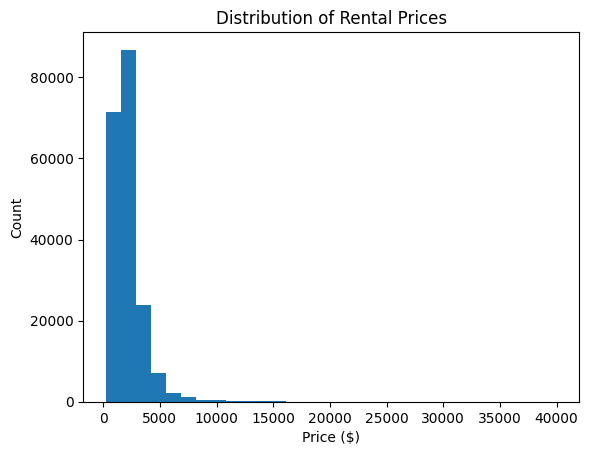

In [19]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

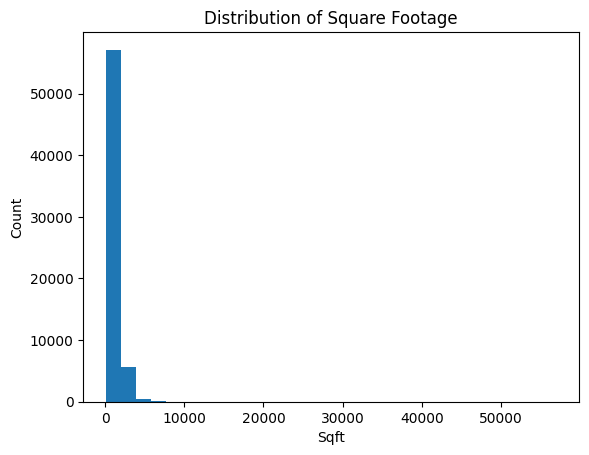

In [20]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


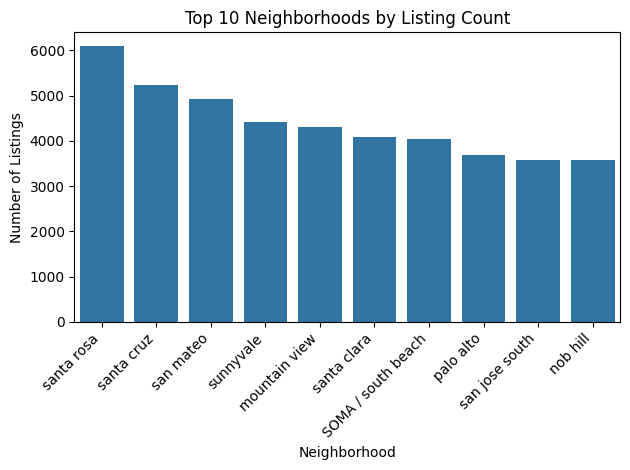

In [21]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

# we have 167 different neighborhoods stored as a categorical variable - lets remove the ones not in the top 10
top_nhoods.index = top_nhoods.index.remove_unused_categories()

# now plot a barplot
sns.barplot(x=top_nhoods.index, y=top_nhoods.values, order = top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself – Part 4

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

2. After creating the visuals, write 1–2 sentences explaining what you notice in each.


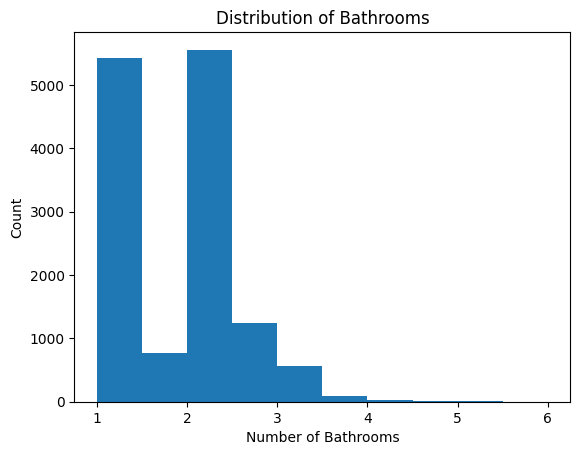

In [30]:
# Visual 1 🔧
plt.hist(df['baths'].dropna(), bins=10)
plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.show()

🔧 Visual 1 comment: The data shows that 1 and 2 bathrooms are far more common than every single other option. The data may also be skewed right due to a few people with more than 3 or 4 bathrooms.

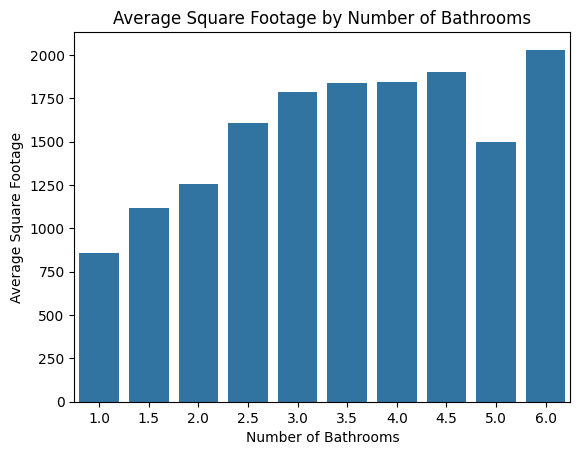

In [31]:
# Visual 2 🔧
avg_sqft_baths = df.groupby('baths')['sqft'].mean().dropna().sort_index()
sns.barplot(x=avg_sqft_baths.index, y=avg_sqft_baths.values)
plt.title("Average Square Footage by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Square Footage")
plt.show()

🔧 Visual 2 comment: As you might expect the number square footage increases as we add more bathrooms (on average). However, the number of bathrooms doesn't appear to have a very significant impact on the square footage because the square footage is very similar when comparing 3-4.5 bathrooms.

## Part 5: Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [24]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.444232,0.424856,0.528037
beds,0.444232,1.000000,0.648323,0.703387
baths,0.424856,0.648323,1.000000,0.641389
sqft,0.528037,0.703387,0.641389,1.000000


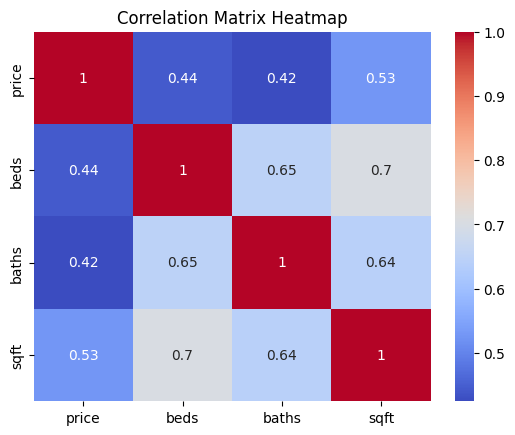

In [25]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

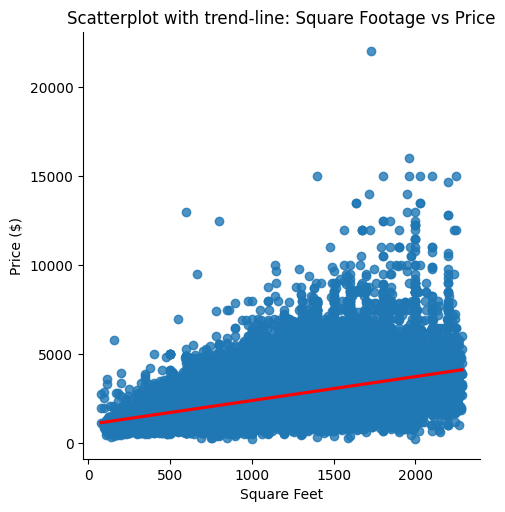

In [26]:
# Scatterplot with a trend line: Square Footage vs Price

# there is a huge outlier in sq footage (see max value is 900,000),
# if you make this plot without removing it, it will not be very useful
# try running it with and without the outliers - to see for yourself

# Remove outliers from sqft using IQR
Q1_sqft = df['sqft'].quantile(0.25)
Q3_sqft = df['sqft'].quantile(0.75)
IQR_sqft = Q3_sqft - Q1_sqft
df = df[((df['sqft'] >= (Q1_sqft - 1.5 * IQR_sqft)) & (df['sqft'] <= (Q3_sqft + 1.5 * IQR_sqft)))]

# now make a scatterplot with a trend line using seaborn's lmplot
sns.lmplot(x='sqft', y='price', data=df, line_kws={"color":"red"})
plt.title("Scatterplot with trend-line: Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

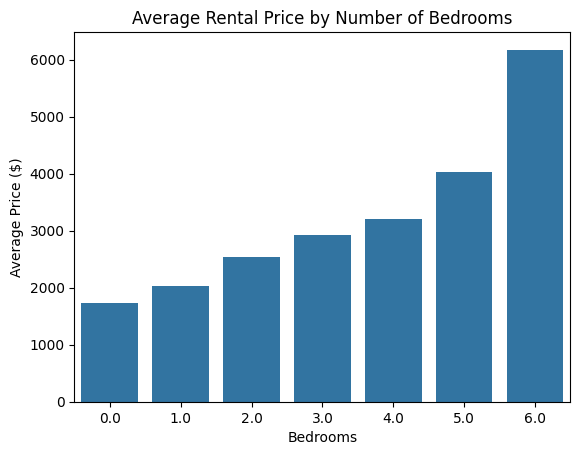

In [27]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### 🔧 Try It Yourself – Part 5

1. Create a scatterplot of `baths` vs `price`.  
2. Group by `year` and plot the average price over time.
3. What trends or outliers do you see?

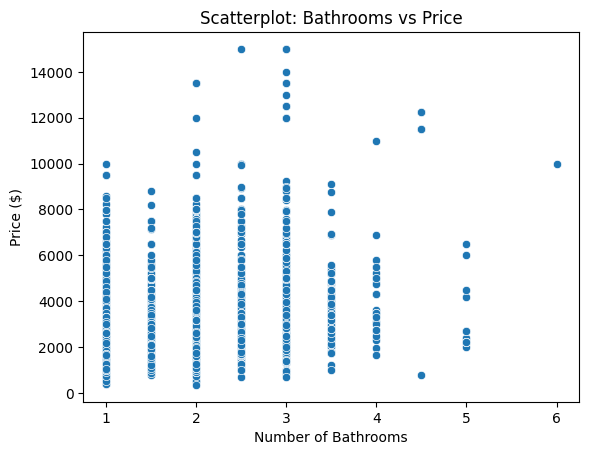

In [32]:
#1 🔧
sns.scatterplot(x='baths', y='price', data=df)
plt.title("Scatterplot: Bathrooms vs Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price ($)")
plt.show()

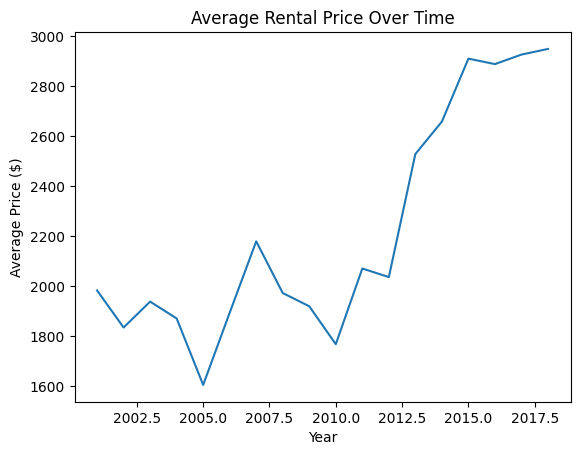

In [33]:
#2 🔧
avg_price_year = df.groupby('year')['price'].mean()
plt.plot(avg_price_year.index, avg_price_year.values)
plt.title("Average Rental Price Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price ($)")
plt.show()

🔧 Add comment here: One outlier that is still present is the 6 bathrooms property. Another outlier appears to be the property the cheapest property with 4.5 bathroom. One trend we see is that since 2010 the rental price increased at what appears to be a much faster rate than prior.

## 🔧  Part 6: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

1. Which variables are most strongly correlated with rental price?
2. Are there patterns in how size (sqft) or number of bedrooms affects price?
3. Which neighborhoods or years show the highest prices?
4. What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

🔧 Add refections here:

1. Number of bedrooms appears to be highly correlated to rental price when looking at the barplot. But furthermore when looking at the correlation matrix it appears that square footage is most highly correlated to price.

2. Square footage upon first glace looks to be linear in terms of price. Furthermore, the number of bedrooms and price appears to be exponentially related.

3. Inverness has the highest average price. Also when it seems that the more recent the year the higher the prices.

4. One grouping I think might improve analysis is total number of rooms compared to price. By including both we may get a more comprehensive understanding of the price similar to how square footage may give a more holistic view. Another valuable metric may be a price per bedroom (or room in general) bar chart to get a better understanding of the impact location has.

In [34]:
!jupyter nbconvert --to html "lab_05_PetersonSteven.ipynb"

[NbConvertApp] Converting notebook lab_05_PetersonSteven.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 10 image(s).
[NbConvertApp] Writing 749832 bytes to lab_05_PetersonSteven.html
